## Question 1.

Train and test accuracies of a decision tree.
Characteristics:
- stratified 80-20 training-test split, fixed seed (random_state=1)
- minimum sample leaf in {1,3,5,10,25,50,100}
- remaining parameters as default

### Step 1: Data preprocessing

- Assess variables and look for missings.
- Categorical variables are already dummified in the original data set (e.g, sex is 0 and 1 instead of male and female).

In [10]:
import pandas as pd
df = pd.read_csv("hungarian_heart_diseases.csv")
df.head()

,age,sex,chest_pain,trestbps,fasting_blood_sugar,restecg,thalach,exercise_induce_angina,oldpeak,outcome
0,28,1,2,130,0,2,185,0,0.0,0
1,29,1,2,120,0,0,160,0,0.0,0
2,29,1,2,140,0,0,170,0,0.0,0
3,30,0,1,170,0,1,170,0,0.0,0
4,31,0,2,100,0,1,150,0,0.0,0


In [11]:
df.value_counts("outcome")

outcome
0    181
1    103
Name: count, dtype: int64

In [12]:
df.isnull().sum()

age                       0
sex                       0
chest_pain                0
trestbps                  0
fasting_blood_sugar       0
restecg                   0
thalach                   0
exercise_induce_angina    0
oldpeak                   0
outcome                   0
dtype: int64

### Step 2: Implementing the decision tree
1. Splitting data (train/test)
2. Training the train data set 
3. Making output predictions
4. Calculating and plotting accuracy

In [13]:
# splitting the data set into inputs (X) and outputs (y)
X = df.iloc[:, 0:9] 
y = df.iloc[:, 9]

X.head()

,age,sex,chest_pain,trestbps,fasting_blood_sugar,restecg,thalach,exercise_induce_angina,oldpeak
0,28,1,2,130,0,2,185,0,0.0
1,29,1,2,120,0,0,160,0,0.0
2,29,1,2,140,0,0,170,0,0.0
3,30,0,1,170,0,1,170,0,0.0
4,31,0,2,100,0,1,150,0,0.0


In [14]:
from sklearn.model_selection import train_test_split
from sklearn import tree, metrics
import numpy as np
import matplotlib.pyplot as plt

# splitting the data set in ratio 80-20 for training and testing, with stratification and fixed seed
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=1)

# Learn classifier
# array with different minimum sample leaves to test
msl = np.array([1,3,5,10,25,50,100])
acc_train = np.zeros(len(msl))
acc_test = np.zeros(len(msl))

for i in range(len(msl)):
    predictor = tree.DecisionTreeClassifier(min_samples_leaf = msl[i], random_state=1)
    # learn from the training data
    predictor.fit(X_train, y_train) 
    # predict on the training data
    y_train_pred = predictor.predict(X_train)
    # compute train accuracy
    acc_train[i] = round(metrics.accuracy_score(y_train, y_train_pred),3)
    # do the same for testing data
    y_pred_test = predictor.predict(X_test)
    acc_test[i] = round(metrics.accuracy_score(y_test, y_pred_test),3)

print(acc_train)
print(acc_test)


[1.    0.907 0.859 0.837 0.811 0.802 0.639]
[0.772 0.789 0.807 0.807 0.86  0.719 0.632]


### Step 3: Plotting the final result

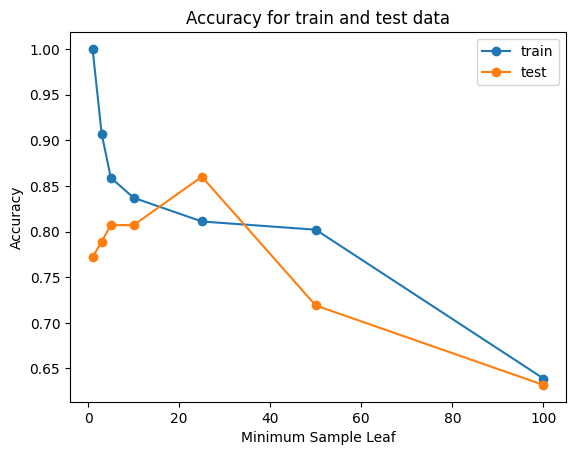

In [15]:
plt.plot(msl, acc_train, marker='o', label='train')
plt.plot(msl, acc_test, marker='o', label='test')
plt.xlabel("Minimum Sample Leaf")
plt.ylabel("Accuracy")
plt.title("Accuracy for train and test data")
plt.legend()
plt.show()

## Question 2. 
### Result Analysis

For the lowest values of minimum sample leaf (1 and 3), the model performs well on the testing data, showing accuracy values in the 85%-100% range. However, the accuracy falls below 80% for the testing data, which may be a minimal overfitting. For the highest values of minimum sample leaf (50 and 100), the accuracy drops below 65% for both data sets at 100 and stays below 75% for the test set. This may mean the model is underfitting: not fitting (learning) the data enough.  

In this work, the accuracy stays in the 80%-90% range for both data sets for the intermediate values of minimum sample leaf (5, 10, 25). Since the accuracy is high not only for the training data set but also for the testing data set, the model in this range shows promise of being effective for generalization to other untrained data sets, while avoiding overfitting.

## Question 3.
- Data set split into training, validation and testing (60-20-20)
- Decision tree maximum depth in [2,4] and minimum sample leaf in [2,100]

3.1) Splitting and fitting train data

In [16]:
# data split same as before, but 60% data training 
X_train2, X_test_val, y_train2, y_test_val = train_test_split(X, y, train_size=0.6, stratify=y, random_state=1)
# split the remaining set into two equal halves: final ratio 60-20-20
X_test2, X_val, y_test2, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5, stratify=y_test_val, random_state=1)

acc_train2 = np.zeros((5,101))
acc_val = np.zeros((5,101))
depth = []
split = []

for i in range(2,5):
    for j in range(2,101):
        predictor = tree.DecisionTreeClassifier(min_samples_split = j, max_depth=i, random_state=1)
        predictor.fit(X_train2, y_train2) 
        # predict on the training data
        y_train_pred2 = predictor.predict(X_train2)
        # compute train accuracy
        acc_train2[i,j] = round(metrics.accuracy_score(y_train2, y_train_pred2),3)
        # do the same for validation data
        y_pred_val = predictor.predict(X_val)
        acc_val = round(metrics.accuracy_score(y_val, y_pred_val),3)
        # selecting parameters for which validation acc >= 0.8
        if acc_val >= 0.8:
            depth.append(i)
            split.append(j)

print(depth)
print(split)


[4, 4, 4, 4, 4]
[2, 3, 4, 5, 6]


3.2) Selecting parameters for above 80% accuracy in validation data and above 78.5% accuracy in test data

In [17]:
print(f"maximum depth: {depth}")
print(f"minimum sample splits: {split}")

acc_test = np.zeros(len(split))

for i in range(len(depth)):
    predictor = tree.DecisionTreeClassifier(min_samples_split = split[i], max_depth=depth[i], random_state=1)
    predictor.fit(X_train2, y_train2)
    y_pred_test2 = predictor.predict(X_test2)
    acc_test[i] = round(metrics.accuracy_score(y_test2, y_pred_test2),3)

print(f"test accuracies: {acc_test}")

maximum depth: [4, 4, 4, 4, 4]
minimum sample splits: [2, 3, 4, 5, 6]
test accuracies: [0.772 0.772 0.754 0.754 0.754]


The threshold for test accuracy was 78.5%, but the maximum test accuracy in our case was 77.2%. Bellow is the plot for one of those trees:

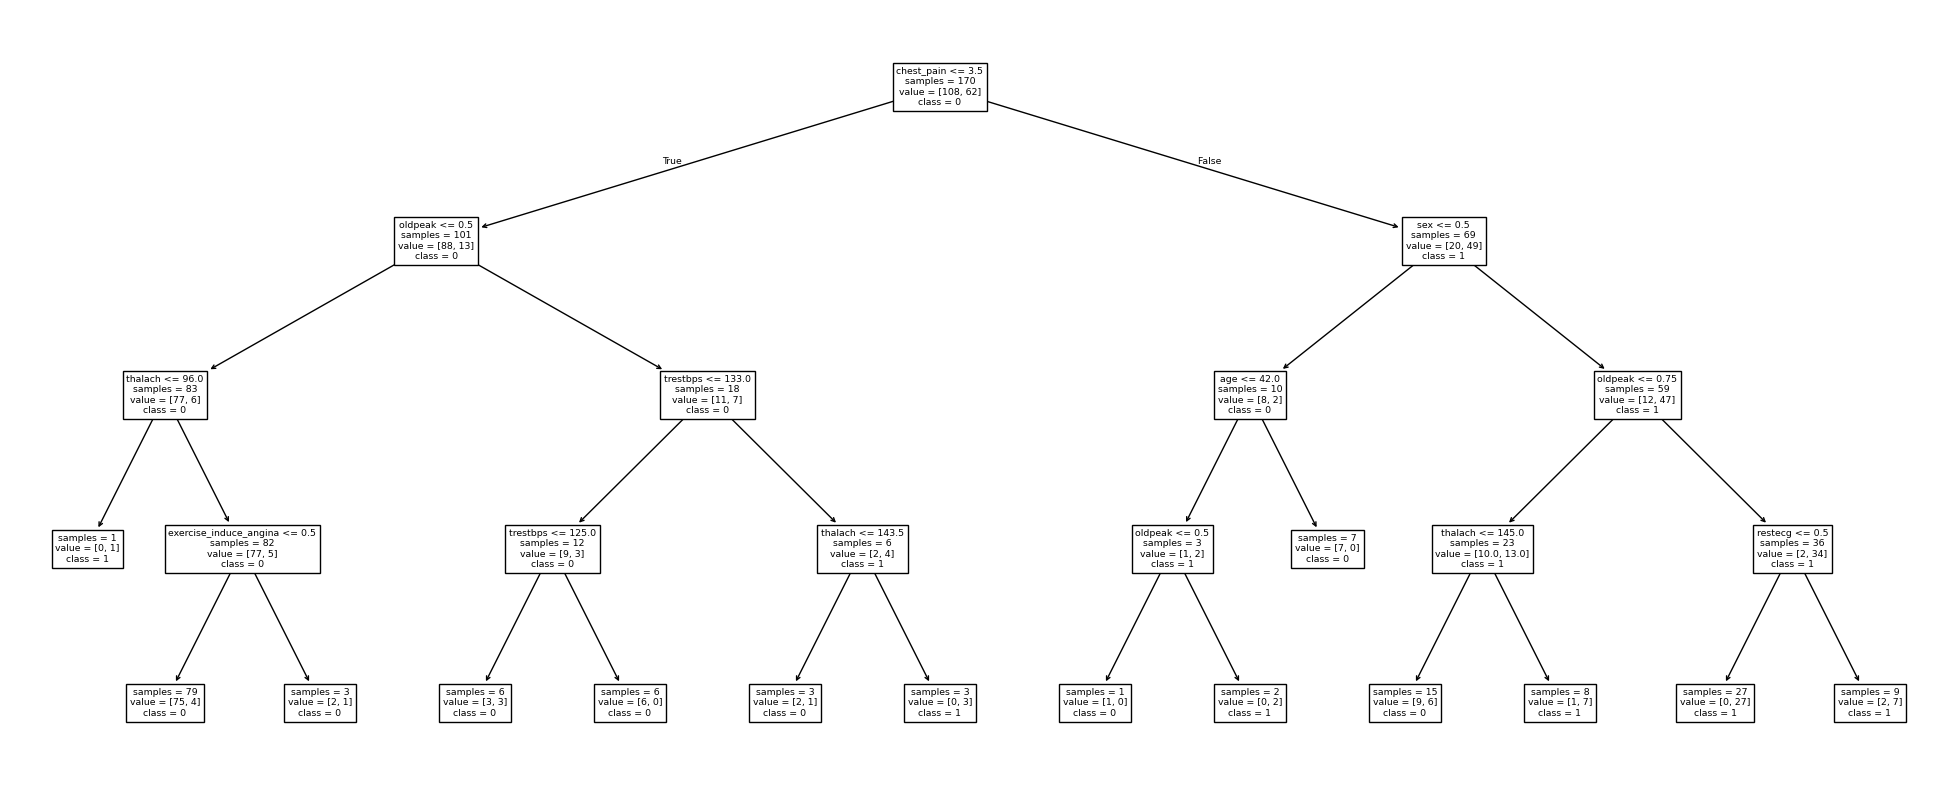

In [18]:
figure = plt.figure(figsize=(25,10))
predictor = tree.DecisionTreeClassifier(min_samples_split = split[1], max_depth=depth[1], random_state=1)
predictor.fit(X_train2, y_train2) 

tree.plot_tree(predictor, feature_names=X.columns.tolist(), class_names=[str(c) for c in y.unique()], impurity=False)
plt.show()

3. ii) To characterize heart diseases, we must look at the leaf nodes of class 1 to calculate their posterior probabilities and check the path that lead to it to get the conditional associations.

-  conditions1 = (chest pain <= 3.5 ^ oldpeak <= 0.5 ^ thalach <= 96.0) => p(class = 1| conditions1) = 1/1 = 1.0
-  conditions2 = (chest pain <= 3.5 ^ oldpeak > 0.5 ^ trestbps > 133.0 ^ thalach > 143.5) => p(class = 1| conditions2) = 3/3 = 1.0
-  conditions3 = (chest pain > 3.5 ^ sex <= 0.5 ^ age <= 42.0 ^ oldpeak > 0.5) => p(class = 1| conditions3) = 2/2 = 1.0
-  conditions4 = (chest pain > 3.5 ^ sex > 0.5 ^ oldpeak <= 0.75 ^ thalach > 145.0) => p(class = 1| conditions4) = 7/8 = 0.875
-  conditions5 = (chest pain > 3.5 ^ sex > 0.5 ^ oldpeak > 0.75 ^ restecg <= 0.5) => p(class = 1| conditions5) = 27/27 = 1.0
-  conditions6 = (chest pain > 3.5 ^ sex > 0.5 ^ oldpeak > 0.75 ^ restecg > 0.5) => p(class = 1| conditions6) = 7/9 = 0.778